# Flight Maneuver Classification

Classify flight maneuvers into 3 classes based on time-series accelerometer data (x, y, z measurements).

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score,
    precision_recall_fscore_support, roc_auc_score
)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load Data

In [2]:
# Load training data
train_df = pd.read_csv('../data/train_set.csv')
test_df = pd.read_csv('../data/test_set.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nTrain columns: {train_df.columns.tolist()}")
print(f"Test columns: {test_df.columns.tolist()}")

Train shape: (799994, 6)
Test shape: (200000, 6)

Train columns: ['maneuver_Id', 'timestamp', 'measurement_x', 'measurement_y', 'measurement_z', 'label']
Test columns: ['Unnamed: 0', 'maneuver_Id', 'timestamp', 'measurement_x', 'measurement_y', 'measurement_z']


In [3]:
# Inspect first rows
print("Training data sample:")
print(train_df.head())
print(f"\nLabel distribution:\n{train_df['label'].value_counts().sort_index()}")

Training data sample:
   maneuver_Id timestamp  measurement_x  measurement_y  measurement_z  label
0            0   50:34.3       0.798000      -0.023776       0.080064      1
1            0   50:34.4       0.795484      -0.031727       0.077065      1
2            0   50:34.4       0.793049      -0.039704       0.077875      1
3            0   50:34.5       0.790697      -0.047705       0.076800      1
4            0   50:34.5       0.788426      -0.055730       0.079076      1

Label distribution:
label
0    541030
1    165979
2     92985
Name: count, dtype: int64


## 3. EDA & Data Visualization

In [4]:
# Data info
print("Missing values:")
print(train_df.isnull().sum())
print(f"\nUnique maneuvers: {train_df['maneuver_Id'].nunique()}")
print(f"Measurements per maneuver: {train_df.groupby('maneuver_Id').size().describe()}")

Missing values:
maneuver_Id        0
timestamp          0
measurement_x    798
measurement_y    156
measurement_z    145
label              0
dtype: int64

Unique maneuvers: 25706
Measurements per maneuver: count    25706.000000
mean        31.120906
std         14.565659
min          1.000000
25%         21.000000
50%         30.000000
75%         40.000000
max        101.000000
dtype: float64


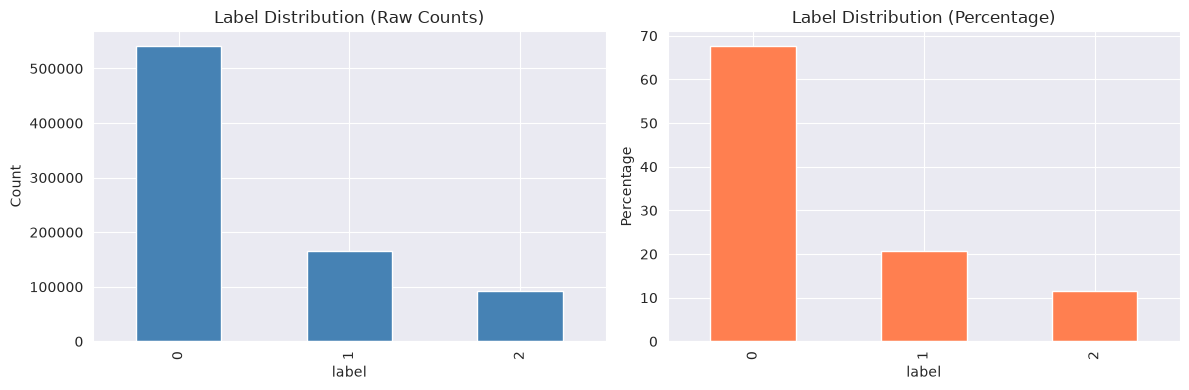

In [5]:
# Visualization: Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df['label'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Label Distribution (Raw Counts)')
axes[0].set_ylabel('Count')

(train_df['label'].value_counts(normalize=True).sort_index() * 100).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Label Distribution (Percentage)')
axes[1].set_ylabel('Percentage')
plt.tight_layout()
plt.show()

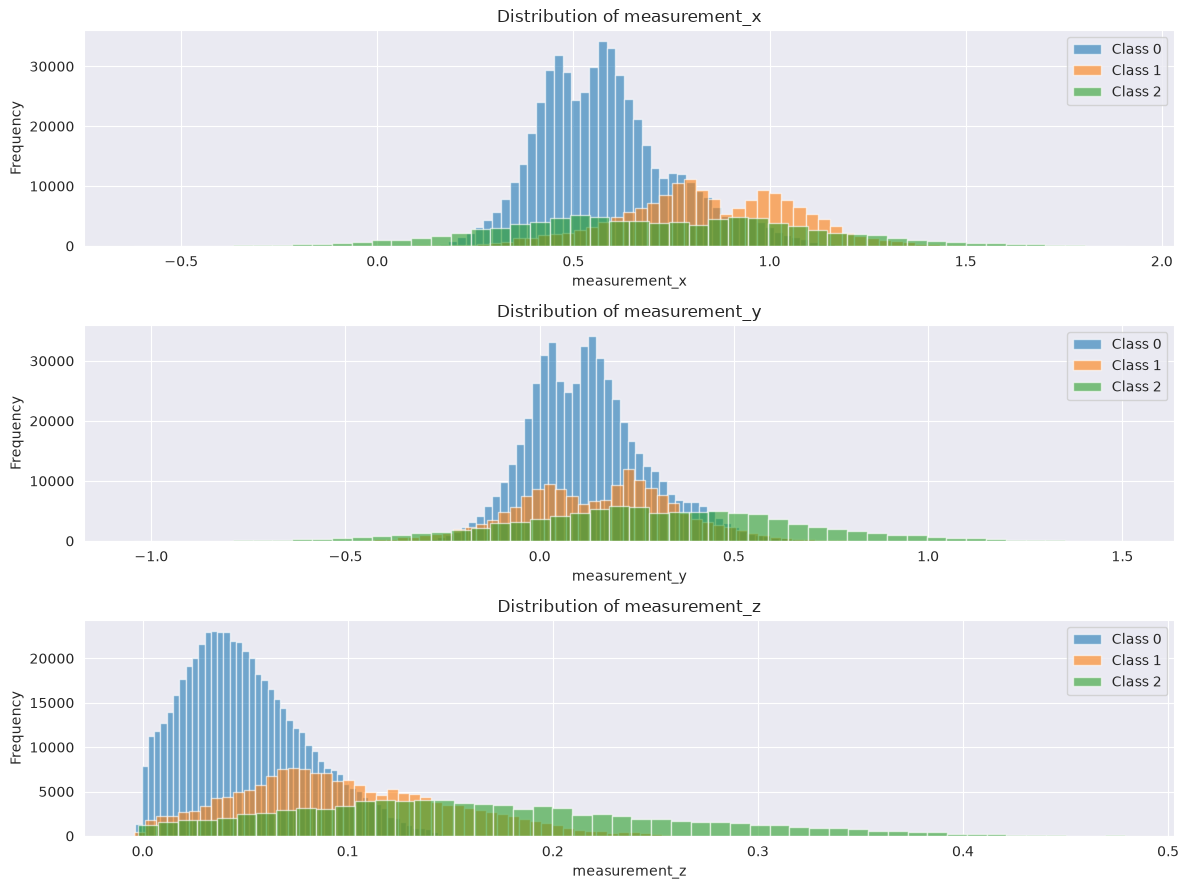

In [6]:
# Visualization: Measurement distributions by label
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
measurements = ['measurement_x', 'measurement_y', 'measurement_z']
for idx, m in enumerate(measurements):
    for label in sorted(train_df['label'].unique()):
        data = train_df[train_df['label'] == label][m]
        axes[idx].hist(data, alpha=0.6, bins=50, label=f'Class {label}')
    axes[idx].set_title(f'Distribution of {m}')
    axes[idx].set_xlabel(m)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
plt.tight_layout()
plt.show()

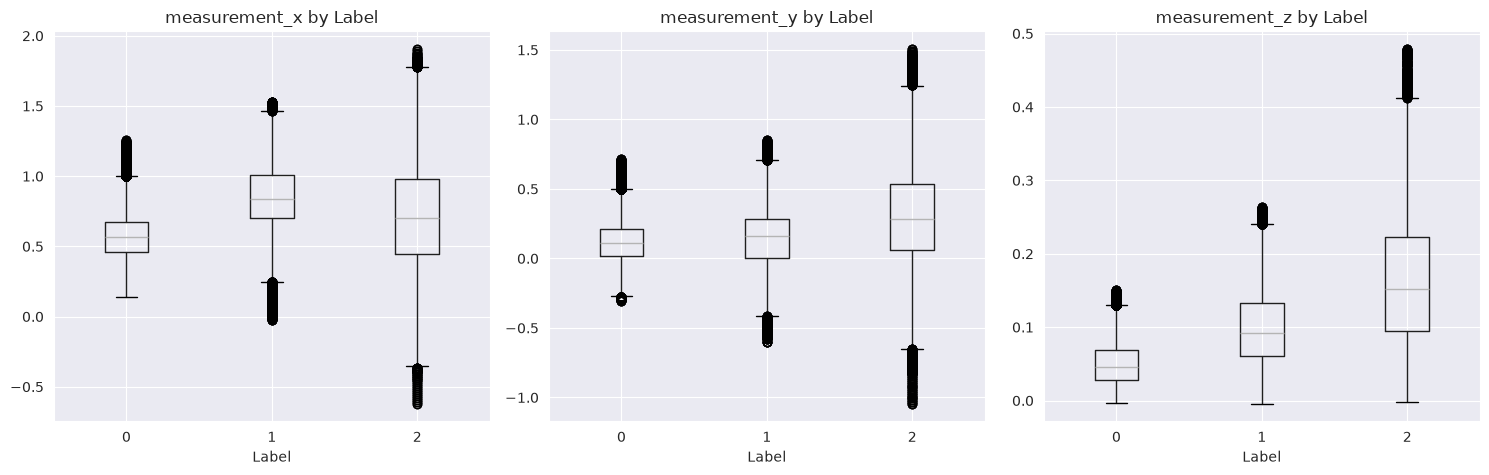

In [7]:
# Boxplots by label
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, m in enumerate(measurements):
    train_df.boxplot(column=m, by='label', ax=axes[idx])
    axes[idx].set_title(f'{m} by Label')
    axes[idx].set_xlabel('Label')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [ ]:
def extract_features(group):
    """Extract statistical features from time-series data for a single maneuver."""
    features = {}
    
    # Basic statistics for each measurement
    for col in ['measurement_x', 'measurement_y', 'measurement_z']:
        features[f'{col}_mean'] = float(group[col].mean())
        features[f'{col}_std'] = float(group[col].std() or 0)
        features[f'{col}_min'] = float(group[col].min())
        features[f'{col}_max'] = float(group[col].max())
        features[f'{col}_median'] = float(group[col].median())
        features[f'{col}_q25'] = float(group[col].quantile(0.25))
        features[f'{col}_q75'] = float(group[col].quantile(0.75))
        features[f'{col}_range'] = float(group[col].max() - group[col].min())
        features[f'{col}_skew'] = float(group[col].skew() or 0)
        features[f'{col}_kurtosis'] = float(group[col].kurtosis() or 0)
    
    # Magnitude of acceleration vector
    group['magnitude'] = np.sqrt(
        group['measurement_x']**2 + 
        group['measurement_y']**2 + 
        group['measurement_z']**2
    )
    features['magnitude_mean'] = float(group['magnitude'].mean())
    features['magnitude_std'] = float(group['magnitude'].std() or 0)
    features['magnitude_max'] = float(group['magnitude'].max())
    
    # Pairwise correlations (safe handling of NaN)
    try:
        corr_matrix = group[['measurement_x', 'measurement_y', 'measurement_z']].corr()
        features['corr_xy'] = float(corr_matrix.loc['measurement_x', 'measurement_y'] or 0)
        features['corr_xz'] = float(corr_matrix.loc['measurement_x', 'measurement_z'] or 0)
        features['corr_yz'] = float(corr_matrix.loc['measurement_y', 'measurement_z'] or 0)
    except:
        features['corr_xy'] = 0.0
        features['corr_xz'] = 0.0
        features['corr_yz'] = 0.0
    
    # Rate of change (derivatives)
    for col in ['measurement_x', 'measurement_y', 'measurement_z']:
        diff = group[col].diff().dropna()
        if len(diff) > 0:
            features[f'{col}_diff_mean'] = float(diff.mean())
            features[f'{col}_diff_std'] = float(diff.std() or 0)
            features[f'{col}_diff_max'] = float(diff.abs().max())
        else:
            features[f'{col}_diff_mean'] = 0.0
            features[f'{col}_diff_std'] = 0.0
            features[f'{col}_diff_max'] = 0.0
    
    # Number of observations
    features['n_observations'] = float(len(group))
    
    return pd.Series(features)

print("Extracting features from training data...")
X_train = train_df.groupby('maneuver_Id').apply(extract_features).reset_index()
y_train = train_df.drop_duplicates('maneuver_Id')[['maneuver_Id', 'label']].set_index('maneuver_Id').loc[X_train['maneuver_Id'], 'label'].values

print(f"Features extracted: {X_train.shape}")
print(f"Feature names: {X_train.columns[1:].tolist()[:10]}...")

In [9]:
# Handle NaN values in features and convert column names to strings
X_train = X_train.fillna(0)
X_train.columns = X_train.columns.astype(str)
print(f"Missing values after fillna: {X_train.isnull().sum().sum()}")
print(f"Column dtypes: {X_train.columns.dtype}")
print(f"\nFeature statistics:\n{X_train.iloc[:, 1:].describe()}")

Missing values after fillna: 0
Column dtypes: str

Feature statistics:
                  0
count  1.180802e+06
mean   7.796294e-01
std    5.047150e+00
min   -5.383292e+00
25%    2.403370e-03
50%    4.282944e-02
75%    3.585702e-01
max    1.010000e+02


In [10]:
# Extract features for test data
print("Extracting features from test data...")
X_test = test_df.groupby('maneuver_Id').apply(extract_features).reset_index()
X_test = X_test.fillna(0)
# Convert columns to strings immediately after extraction
X_test.columns = X_test.columns.astype(str)
print(f"Test features extracted: {X_test.shape}")

Extracting features from test data...
Test features extracted: (291948, 3)


# Drop maneuver_Id and prepare for modeling
feature_cols = X_train.columns[1:].tolist()
X_train_features = X_train[feature_cols]
X_test_features = X_test[feature_cols]

print(f"Feature columns dtype: {X_train_features.columns.dtype}")
print(f"Features: {len(feature_cols)}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

In [ ]:
# Drop maneuver_Id and prepare for modeling
feature_cols = X_train.columns[1:].tolist()
X_train_features = X_train[feature_cols].copy()
X_test_features = X_test[feature_cols].copy()

print(f"Feature columns: {len(feature_cols)}")
print(f"X_train_features dtypes (unique): {X_train_features.dtypes.unique()}")
print(f"X_train_features shape: {X_train_features.shape}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

## 6. Model Training & Cross-Validation

In [ ]:
# Define models
models = {
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42
    )
}

# Cross-validation setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

In [ ]:
# Train and evaluate each model
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    cv_scores = cross_validate(
        model, X_train_scaled, y_train,
        cv=skf,
        scoring=['accuracy', 'f1_weighted', 'f1_macro'],
        return_train_score=True,
        n_jobs=-1
    )
    
    cv_results[model_name] = cv_scores
    
    print(f"  Accuracy: {cv_scores['test_accuracy'].mean():.4f} (+/- {cv_scores['test_accuracy'].std():.4f})")
    print(f"  F1 (weighted): {cv_scores['test_f1_weighted'].mean():.4f} (+/- {cv_scores['test_f1_weighted'].std():.4f})")
    print(f"  F1 (macro): {cv_scores['test_f1_macro'].mean():.4f} (+/- {cv_scores['test_f1_macro'].std():.4f})")

In [ ]:
# Train final model on full training set
best_model_name = 'XGBoost'  # Can be updated based on CV results
final_model = models[best_model_name]
print(f"Training final {best_model_name} model on full training set...")
final_model.fit(X_train_scaled, y_train)
print("Done!")

## 7. Evaluation on Training Set

In [ ]:
# Predictions on training set
y_pred_train = final_model.predict(X_train_scaled)
y_pred_proba_train = final_model.predict_proba(X_train_scaled)

# Classification report
print("Classification Report (Training Set):\n")
print(classification_report(y_train, y_pred_train, target_names=['Class 0', 'Class 1', 'Class 2']))

In [ ]:
# Per-class F1 scores
precision, recall, f1, support = precision_recall_fscore_support(y_train, y_pred_train, average=None)
print("\nPer-Class Metrics:")
for i in range(len(np.unique(y_train))):
    print(f"Class {i}: Precision={precision[i]:.4f}, Recall={recall[i]:.4f}, F1={f1[i]:.4f}")
print(f"\nMinimum F1 (Final Score): {min(f1):.4f}")

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_train, y_pred_train)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1', 'Class 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.title('Confusion Matrix (Training Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 8. Feature Importance

In [ ]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features:")
print(feature_importance.head(20))

In [ ]:
# Plot feature importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance')
plt.tight_layout()
plt.show()

## 9. Test Set Predictions

In [ ]:
# Make predictions on test set
y_pred_test = final_model.predict(X_test_scaled)

# Create submission file
submission = pd.DataFrame({
    'maneuver_id': X_test['maneuver_Id'],
    'class': y_pred_test
})

submission.to_csv('../output/submission.csv', index=False)
print(f"Submission saved! Shape: {submission.shape}")
print(f"\nClass distribution in submission:")
print(submission['class'].value_counts().sort_index())

In [ ]:
print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Model: {best_model_name}")
print(f"Training Accuracy: {(y_pred_train == y_train).mean():.4f}")
print(f"Minimum F1 Score: {min(f1):.4f}")
print(f"Test predictions saved to: ../output/submission.csv")